In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from Features_SupplyBins import *
from Analysis_SupplyBins import *

pd.set_option('display.max_columns', None)

In [67]:
def plot_bad_rate(data, column, target='loan_status', value_ranges=None):
    # Calculate bad rate
    bad_rate = data.groupby(column)[target].mean().reset_index()
    bad_rate.columns = [column, 'Bad_Rate']

    # Calculate count and percentage population
    counts = data[column].value_counts(dropna=False).reset_index()
    counts.columns = [column, 'Count']
    counts['% Population'] = (counts['Count'] / len(data)) * 100

    # Merge bad rate and counts
    merged = pd.merge(bad_rate, counts, on=column)

    # Sort the merged data for better visualization
    merged = merged.sort_values(by=column)

    if value_ranges is not None:
        merged['Value_Range'] = value_ranges

    # Create bar plot for percentage population
    fig = px.bar(merged, x=column, y='% Population',
                 text=merged['Count'],
                 hover_name = merged['Value_Range'],
                 title=f'Bad Rate and % Population by {column}',
                 labels={column: column, '% Population': '% Population'})

    # Update bar plot to show count on bars
    fig.update_traces(textposition='outside')

    # Add line plot for bad rate
    fig.add_trace(
        go.Scatter(x=merged[column], y=merged['Bad_Rate'],
                   mode='lines+markers',
                   name='Bad Rate',
                   yaxis='y2')
    )

    # Update layout for dual y-axes
    fig.update_layout(
        uniformtext_minsize=8,
        uniformtext_mode='hide',
        yaxis=dict(
            title='% Population',
            tickformat='.2f'
        ),
        yaxis2=dict(
            title='Bad Rate',
            overlaying='y',
            side='right',
            tickformat='.2%'
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        ),
        height=600
    )

    fig.show()
    display(merged)
    return merged

In [68]:
def CAT_plot_bad_rate(data, column, target='loan_status', value_ranges=None):
    # Calculate bad rate
    bad_rate = data.groupby(column)[target].mean().reset_index()
    bad_rate.columns = [column, 'Bad_Rate']

    # Calculate count and percentage population
    counts = data[column].value_counts(dropna=False).reset_index()
    counts.columns = [column, 'Count']
    counts['% Population'] = (counts['Count'] / len(data)) * 100

    # Merge bad rate and counts
    merged = pd.merge(bad_rate, counts, on=column)

    # Sort the merged data for better visualization
    merged = merged.sort_values(by=['Bad_Rate'])

    if value_ranges is not None:
        merged['Value_Range'] = value_ranges

    # Create bar plot for percentage population
    fig = px.bar(merged, x=column, y='% Population',
                 text=merged['Count'],
                 hover_name = merged['Value_Range'],
                 title=f'Bad Rate and % Population by {column}',
                 labels={column: column, '% Population': '% Population'})

    # Update bar plot to show count on bars
    fig.update_traces(textposition='outside')

    # Add line plot for bad rate
    fig.add_trace(
        go.Scatter(x=merged[column], y=merged['Bad_Rate'],
                   mode='lines+markers',
                   name='Bad Rate',
                   yaxis='y2')
    )

    # Update layout for dual y-axes
    fig.update_layout(
        uniformtext_minsize=8,
        uniformtext_mode='hide',
        yaxis=dict(
            title='% Population',
            tickformat='.2f'
        ),
        yaxis2=dict(
            title='Bad Rate',
            overlaying='y',
            side='right',
            tickformat='.2%'
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        ),
        height=600
    )

    fig.show()
    display(merged)
    return merged

In [69]:
data = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/Scorecard_Project/loan_data.csv')

In [70]:
def plot_bad_rate_num_updated(data, num_column, lstbin, target='loan_status'):

    data[f'{num_column}_binned'], bins = pd.cut(data[num_column], lstbin, labels=False, retbins=True,  duplicates='drop')
    value_ranges = [f'{bins[i]:.2f} - {bins[i+1]:.2f}' for i in range(len(bins)-1)]
    merged = plot_bad_rate(data, f'{num_column}_binned', target, value_ranges=value_ranges)
    describe_table = pd.DataFrame(data[num_column].describe())
    display(describe_table)
    return merged

In [71]:
def CAT_plot_bad_rate_num_updated(data, num_column, lstbin, target='loan_status'):

    data[f'{num_column}_binned'] = data[num_column]
    value_ranges = [lstbin[i] for i in range(len(lstbin))]
    merged = CAT_plot_bad_rate(data, f'{num_column}_binned', target, value_ranges=value_ranges)
    describe_table = pd.DataFrame(data[num_column].describe())
    display(describe_table)
    return merged

In [72]:
data.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


## person_income

In [73]:
var = 'person_income'

In [74]:
data[var].isna().sum()

np.int64(0)

In [75]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [76]:
init_lstbin = list(bintest)

In [77]:
init_lstbin

[np.float64(8000.0),
 np.float64(35118.9),
 np.float64(43081.8),
 np.float64(51221.0),
 np.float64(59456.000000000015),
 np.float64(67048.0),
 np.float64(76436.80000000002),
 np.float64(88474.9),
 np.float64(103841.00000000004),
 np.float64(133276.1),
 np.float64(7200766.0)]

### Int Bins

In [78]:
lstbin = [np.float64(8000.0),
 np.float64(35118.9),
 np.float64(43081.8),
 np.float64(51221.0),
 np.float64(59456.000000000015),
 np.float64(67048.0),
 np.float64(76436.80000000002),
 np.float64(88474.9),
 np.float64(103841.00000000004),
 np.float64(133276.1),
 np.float64(7200766.0)]

In [79]:
len(data)

45000

In [80]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,person_income_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.476477,4485,9.966667,8000.00 - 35118.90
1,1.0,0.404889,4500,10.000000,35118.90 - 43081.80
2,2.0,0.238169,4501,10.002222,43081.80 - 51221.00
3,3.0,0.226939,4499,9.997778,51221.00 - 59456.00
4,4.0,0.212397,4501,10.002222,59456.00 - 67048.00
5,5.0,0.182263,4499,9.997778,67048.00 - 76436.80
6,6.0,0.152000,4500,10.000000,76436.80 - 88474.90
7,7.0,0.140889,4500,10.000000,88474.90 - 103841.00
8,8.0,0.095778,4500,10.000000,103841.00 - 133276.10
9,9.0,0.090667,4500,10.000000,133276.10 - 7200766.00


,person_income
count,4.500000e+04
mean,8.031905e+04
std,8.042250e+04
min,8.000000e+03
25%,4.720400e+04
50%,6.704800e+04
75%,9.578925e+04
max,7.200766e+06


In [81]:
data[var + '_binned'].nunique()

10

In [82]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [83]:
iv = IV_SupplyBins()

In [84]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,person_income_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4485,2137,26735.823634,2348,0.476477,10.0,0.067086,0.214021,-0.146935,-1.160103,0.170460
1,1.0,4500,1822,39014.103778,2678,0.404889,9.0,0.076514,0.182474,-0.105959,-0.869129,0.092092
2,2.0,4501,1072,47031.197512,3429,0.238169,8.0,0.097971,0.107361,-0.009390,-0.091521,0.000859
3,3.0,4499,1021,55164.348522,3478,0.226939,7.0,0.099371,0.102253,-0.002882,-0.028589,0.000082
4,4.0,4501,956,63185.055988,3545,0.212397,6.0,0.101286,0.095744,0.005542,0.056271,0.000312
5,5.0,4499,820,71839.245166,3679,0.182263,5.0,0.105114,0.082123,0.022991,0.246828,0.005675
6,6.0,4500,684,82373.312222,3816,0.152000,4.0,0.109029,0.068503,0.040526,0.464736,0.018834
7,7.0,4500,634,95725.697778,3866,0.140889,3.0,0.110457,0.063495,0.046962,0.553663,0.026001
8,8.0,4500,431,117445.534889,4069,0.095778,2.0,0.116257,0.043165,0.073092,0.990780,0.072419
9,9.0,4500,408,204742.396000,4092,0.090667,1.0,0.116914,0.040861,0.076053,1.051258,0.079951


Information value:  0.4666856208220811


### Modified Bin

In [85]:
len(data)

45000

In [86]:
lstbin = [np.float64(8000.0),
 np.float64(35118.9),
 np.float64(43081.8),
 np.float64(59456.000000000015),
 np.float64(67048.0),
 np.float64(76436.80000000002),
 np.float64(103841.00000000004),
 np.float64(133276.1),
 np.float64(7200766.0)]

In [87]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,person_income_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.476477,4485,9.966667,8000.00 - 35118.90
1,1.0,0.404889,4500,10.000000,35118.90 - 43081.80
2,2.0,0.232556,9000,20.000000,43081.80 - 59456.00
3,3.0,0.212397,4501,10.002222,59456.00 - 67048.00
4,4.0,0.182263,4499,9.997778,67048.00 - 76436.80
5,5.0,0.146444,9000,20.000000,76436.80 - 103841.00
6,6.0,0.095778,4500,10.000000,103841.00 - 133276.10
7,7.0,0.090667,4500,10.000000,133276.10 - 7200766.00


,person_income
count,4.500000e+04
mean,8.031905e+04
std,8.042250e+04
min,8.000000e+03
25%,4.720400e+04
50%,6.704800e+04
75%,9.578925e+04
max,7.200766e+06


In [88]:
data[var + '_binned'].nunique()

8

In [89]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [90]:
iv = IV_SupplyBins()

In [91]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,person_income_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4485,2137,26735.823634,2348,0.476477,8.0,0.067086,0.214021,-0.146935,-1.160103,0.170460
1,1.0,4500,1822,39014.103778,2678,0.404889,7.0,0.076514,0.182474,-0.105959,-0.869129,0.092092
2,2.0,9000,2093,51096.869333,6907,0.232556,6.0,0.197343,0.209614,-0.012272,-0.060327,0.000740
3,3.0,4501,956,63185.055988,3545,0.212397,5.0,0.101286,0.095744,0.005542,0.056271,0.000312
4,4.0,4499,820,71839.245166,3679,0.182263,4.0,0.105114,0.082123,0.022991,0.246828,0.005675
5,5.0,9000,1318,89049.505000,7682,0.146444,3.0,0.219486,0.131998,0.087488,0.508500,0.044488
6,6.0,4500,431,117445.534889,4069,0.095778,2.0,0.116257,0.043165,0.073092,0.990780,0.072419
7,7.0,4500,408,204742.396000,4092,0.090667,1.0,0.116914,0.040861,0.076053,1.051258,0.079951


Information value:  0.46613686922054987


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

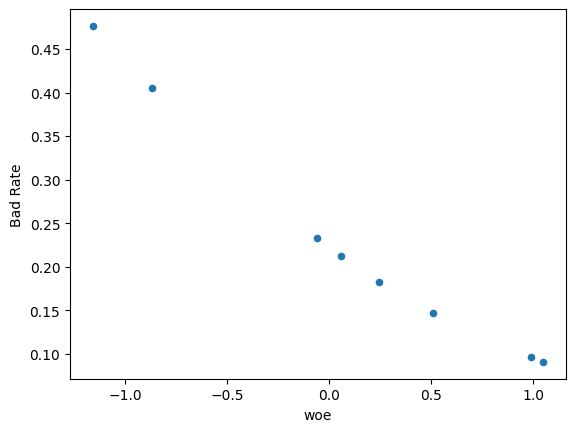

In [92]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [93]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [94]:
merged

,person_income_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.476477,4485,9.966667,8000.00 - 35118.90
1,1.0,0.404889,4500,10.000000,35118.90 - 43081.80
2,2.0,0.232556,9000,20.000000,43081.80 - 59456.00
3,3.0,0.212397,4501,10.002222,59456.00 - 67048.00
4,4.0,0.182263,4499,9.997778,67048.00 - 76436.80
5,5.0,0.146444,9000,20.000000,76436.80 - 103841.00
6,6.0,0.095778,4500,10.000000,103841.00 - 133276.10
7,7.0,0.090667,4500,10.000000,133276.10 - 7200766.00


In [95]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [96]:
merged_final

,person_income_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.476477,4485,9.966667,8000.00 - 35118.90,4485,2137,26735.823634,2348,0.476477,8.0,0.067086,0.214021,-0.146935,-1.160103,0.170460,-0.094161
1,1.0,0.404889,4500,10.000000,35118.90 - 43081.80,4500,1822,39014.103778,2678,0.404889,7.0,0.076514,0.182474,-0.105959,-0.869129,0.092092,-0.385135
2,2.0,0.232556,9000,20.000000,43081.80 - 59456.00,9000,2093,51096.869333,6907,0.232556,6.0,0.197343,0.209614,-0.012272,-0.060327,0.000740,-1.193937
3,3.0,0.212397,4501,10.002222,59456.00 - 67048.00,4501,956,63185.055988,3545,0.212397,5.0,0.101286,0.095744,0.005542,0.056271,0.000312,-1.310536
4,4.0,0.182263,4499,9.997778,67048.00 - 76436.80,4499,820,71839.245166,3679,0.182263,4.0,0.105114,0.082123,0.022991,0.246828,0.005675,-1.501092
5,5.0,0.146444,9000,20.000000,76436.80 - 103841.00,9000,1318,89049.505000,7682,0.146444,3.0,0.219486,0.131998,0.087488,0.508500,0.044488,-1.762764
6,6.0,0.095778,4500,10.000000,103841.00 - 133276.10,4500,431,117445.534889,4069,0.095778,2.0,0.116257,0.043165,0.073092,0.990780,0.072419,-2.245044
7,7.0,0.090667,4500,10.000000,133276.10 - 7200766.00,4500,408,204742.396000,4092,0.090667,1.0,0.116914,0.040861,0.076053,1.051258,0.079951,-2.305522


In [97]:
lstbin

[np.float64(8000.0),
 np.float64(35118.9),
 np.float64(43081.8),
 np.float64(59456.000000000015),
 np.float64(67048.0),
 np.float64(76436.80000000002),
 np.float64(103841.00000000004),
 np.float64(133276.1),
 np.float64(7200766.0)]

In [98]:
list(merged_final['Value_Range'])

['8000.00 - 35118.90',
 '35118.90 - 43081.80',
 '43081.80 - 59456.00',
 '59456.00 - 67048.00',
 '67048.00 - 76436.80',
 '76436.80 - 103841.00',
 '103841.00 - 133276.10',
 '133276.10 - 7200766.00']

In [99]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'8000.00 - 35118.90': -1.1601031689927956,
 '35118.90 - 43081.80': -0.8691286461904209,
 '43081.80 - 59456.00': -0.060327147978661934,
 '59456.00 - 67048.00': 0.05627143129319151,
 '67048.00 - 76436.80': 0.24682782022484037,
 '76436.80 - 103841.00': 0.5085003992217624,
 '103841.00 - 133276.10': 0.9907803632763069,
 '133276.10 - 7200766.00': 1.0512578580457204}

## person_emp_exp

In [100]:
var = 'person_emp_exp'

In [101]:
data[var].isna().sum()

np.int64(0)

In [102]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [103]:
init_lstbin = list(bintest)

In [104]:
init_lstbin

[np.float64(0.0),
 np.float64(1.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(7.0),
 np.float64(9.0),
 np.float64(13.0),
 np.float64(125.0)]

### Int Bins

In [105]:
lstbin = [0.0, 1.0, 3.0, 4.0, 5.0, 7.0, 9.0, 13.0, 125.0]

In [106]:
len(data)

45000

In [107]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,person_emp_exp_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227776,4061,9.024444,0.00 - 1.00
1,1.0,0.223330,8024,17.831111,1.00 - 3.00
2,2.0,0.209989,3524,7.831111,3.00 - 4.00
3,3.0,0.216667,3000,6.666667,4.00 - 5.00
4,4.0,0.215200,4921,10.935556,5.00 - 7.00
5,5.0,0.215007,3465,7.700000,7.00 - 9.00
6,6.0,0.207811,4225,9.388889,9.00 - 13.00
7,7.0,0.210726,4214,9.364444,13.00 - 125.00


,person_emp_exp
count,45000.000000
mean,5.410333
std,6.063532
min,0.000000
25%,1.000000
50%,4.000000
75%,8.000000
max,125.000000


In [108]:
data[var + '_binned'].nunique()

8

In [109]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [110]:
iv = IV_SupplyBins()

In [111]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,person_emp_exp_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4061,925,1.000000,3136,0.227776,8.0,0.112981,0.120490,-0.007509,-0.064350,4.832180e-04
1,1.0,8024,1792,2.484796,6232,0.223330,7.0,0.224520,0.233425,-0.008905,-0.038894,3.463365e-04
2,2.0,3524,740,4.000000,2784,0.209989,2.0,0.100299,0.096392,0.003907,0.039735,1.552513e-04
3,3.0,3000,650,5.000000,2350,0.216667,6.0,0.084663,0.084668,-0.000005,-0.000061,3.147376e-10
4,4.0,4921,1059,6.447876,3862,0.215200,5.0,0.139136,0.137945,0.001192,0.008601,1.024853e-05
5,5.0,3465,745,8.454545,2720,0.215007,4.0,0.097993,0.097043,0.000950,0.009744,9.258325e-06
6,6.0,4225,878,11.255385,3347,0.207811,1.0,0.120582,0.114368,0.006215,0.052914,3.288389e-04
7,7.0,4214,888,19.409350,3326,0.210726,3.0,0.119826,0.115670,0.004155,0.035295,1.466652e-04


Information value:  0.0014798170031851186


### Modified Bin

In [112]:
len(data)

45000

In [113]:
lstbin = [0.0, 1.0, 3.0, 4.0, 5.0, 7.0, 9.0, 13.0, 125.0]


In [114]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,person_emp_exp_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227776,4061,9.024444,0.00 - 1.00
1,1.0,0.223330,8024,17.831111,1.00 - 3.00
2,2.0,0.209989,3524,7.831111,3.00 - 4.00
3,3.0,0.216667,3000,6.666667,4.00 - 5.00
4,4.0,0.215200,4921,10.935556,5.00 - 7.00
5,5.0,0.215007,3465,7.700000,7.00 - 9.00
6,6.0,0.207811,4225,9.388889,9.00 - 13.00
7,7.0,0.210726,4214,9.364444,13.00 - 125.00


,person_emp_exp
count,45000.000000
mean,5.410333
std,6.063532
min,0.000000
25%,1.000000
50%,4.000000
75%,8.000000
max,125.000000


In [115]:
data[var + '_binned'].nunique()

8

In [116]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [117]:
iv = IV_SupplyBins()

In [118]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,person_emp_exp_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4061,925,1.000000,3136,0.227776,8.0,0.112981,0.120490,-0.007509,-0.064350,4.832180e-04
1,1.0,8024,1792,2.484796,6232,0.223330,7.0,0.224520,0.233425,-0.008905,-0.038894,3.463365e-04
2,2.0,3524,740,4.000000,2784,0.209989,2.0,0.100299,0.096392,0.003907,0.039735,1.552513e-04
3,3.0,3000,650,5.000000,2350,0.216667,6.0,0.084663,0.084668,-0.000005,-0.000061,3.147376e-10
4,4.0,4921,1059,6.447876,3862,0.215200,5.0,0.139136,0.137945,0.001192,0.008601,1.024853e-05
5,5.0,3465,745,8.454545,2720,0.215007,4.0,0.097993,0.097043,0.000950,0.009744,9.258325e-06
6,6.0,4225,878,11.255385,3347,0.207811,1.0,0.120582,0.114368,0.006215,0.052914,3.288389e-04
7,7.0,4214,888,19.409350,3326,0.210726,3.0,0.119826,0.115670,0.004155,0.035295,1.466652e-04


Information value:  0.0014798170031851186


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

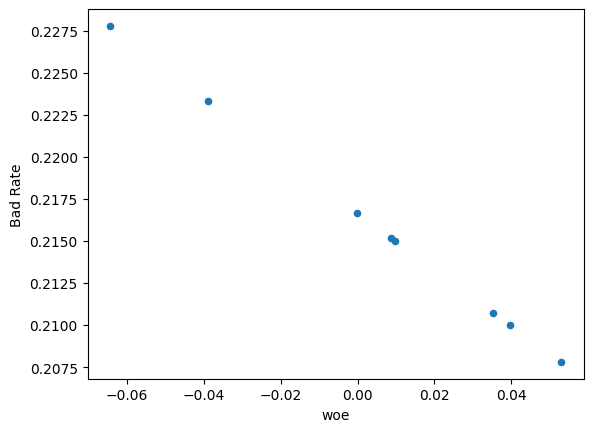

In [119]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [120]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [121]:
merged

,person_emp_exp_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227776,4061,9.024444,0.00 - 1.00
1,1.0,0.223330,8024,17.831111,1.00 - 3.00
2,2.0,0.209989,3524,7.831111,3.00 - 4.00
3,3.0,0.216667,3000,6.666667,4.00 - 5.00
4,4.0,0.215200,4921,10.935556,5.00 - 7.00
5,5.0,0.215007,3465,7.700000,7.00 - 9.00
6,6.0,0.207811,4225,9.388889,9.00 - 13.00
7,7.0,0.210726,4214,9.364444,13.00 - 125.00


In [122]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [123]:
merged_final

,person_emp_exp_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.227776,4061,9.024444,0.00 - 1.00,4061,925,1.000000,3136,0.227776,8.0,0.112981,0.120490,-0.007509,-0.064350,4.832180e-04,-1.220910
1,1.0,0.223330,8024,17.831111,1.00 - 3.00,8024,1792,2.484796,6232,0.223330,7.0,0.224520,0.233425,-0.008905,-0.038894,3.463365e-04,-1.246365
2,2.0,0.209989,3524,7.831111,3.00 - 4.00,3524,740,4.000000,2784,0.209989,2.0,0.100299,0.096392,0.003907,0.039735,1.552513e-04,-1.324994
3,3.0,0.216667,3000,6.666667,4.00 - 5.00,3000,650,5.000000,2350,0.216667,6.0,0.084663,0.084668,-0.000005,-0.000061,3.147376e-10,-1.285198
4,4.0,0.215200,4921,10.935556,5.00 - 7.00,4921,1059,6.447876,3862,0.215200,5.0,0.139136,0.137945,0.001192,0.008601,1.024853e-05,-1.293860
5,5.0,0.215007,3465,7.700000,7.00 - 9.00,3465,745,8.454545,2720,0.215007,4.0,0.097993,0.097043,0.000950,0.009744,9.258325e-06,-1.295003
6,6.0,0.207811,4225,9.388889,9.00 - 13.00,4225,878,11.255385,3347,0.207811,1.0,0.120582,0.114368,0.006215,0.052914,3.288389e-04,-1.338173
7,7.0,0.210726,4214,9.364444,13.00 - 125.00,4214,888,19.409350,3326,0.210726,3.0,0.119826,0.115670,0.004155,0.035295,1.466652e-04,-1.320554


In [124]:
lstbin

[0.0, 1.0, 3.0, 4.0, 5.0, 7.0, 9.0, 13.0, 125.0]

In [125]:
list(merged_final['Value_Range'])

['0.00 - 1.00',
 '1.00 - 3.00',
 '3.00 - 4.00',
 '4.00 - 5.00',
 '5.00 - 7.00',
 '7.00 - 9.00',
 '9.00 - 13.00',
 '13.00 - 125.00']

In [126]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'0.00 - 1.00': -0.06434957083081097,
 '1.00 - 3.00': -0.03889422077297596,
 '3.00 - 4.00': 0.039734620467410726,
 '4.00 - 5.00': -6.097054016235154e-05,
 '5.00 - 7.00': 0.008600902598369051,
 '7.00 - 9.00': 0.00974372612179926,
 '9.00 - 13.00': 0.05291389278752555,
 '13.00 - 125.00': 0.035294701972018734}

## loan_amnt

In [127]:
var = 'loan_amnt'

In [128]:
data[var].isna().sum()

np.int64(0)

In [129]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [130]:
init_lstbin = list(bintest)

In [131]:
init_lstbin

[np.float64(500.0),
 np.float64(3000.0),
 np.float64(4400.0),
 np.float64(5400.0),
 np.float64(6600.0),
 np.float64(8000.0),
 np.float64(10000.0),
 np.float64(12000.0),
 np.float64(14520.200000000026),
 np.float64(19200.0),
 np.float64(35000.0)]

### Int Bins

In [132]:
lstbin = [500.0,
 3000.0,
 4400.0,
 5400.0,
 6600.0,
 8000.0,
 10000.0,
 12000.0,
 14520.200000000026,
 19200.0,
 35000.0]

In [133]:
len(data)

45000

In [134]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,loan_amnt_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.209370,5464,12.142222,500.00 - 3000.00
1,1.0,0.218706,3571,7.935556,3000.00 - 4400.00
2,2.0,0.194938,4504,10.008889,4400.00 - 5400.00
3,3.0,0.157140,4461,9.913333,5400.00 - 6600.00
4,4.0,0.176043,5226,11.613333,6600.00 - 8000.00
5,5.0,0.204455,6510,14.466667,8000.00 - 10000.00
6,6.0,0.203675,3918,8.706667,10000.00 - 12000.00
7,7.0,0.256728,2341,5.202222,12000.00 - 14520.20
8,8.0,0.285335,4521,10.046667,14520.20 - 19200.00
9,9.0,0.347399,4479,9.953333,19200.00 - 35000.00


,loan_amnt
count,45000.000000
mean,9583.157556
std,6314.886691
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12237.250000
max,35000.000000


In [135]:
data[var + '_binned'].nunique()

10

In [136]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [137]:
iv = IV_SupplyBins()

In [138]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,loan_amnt_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,5464,1144,2209.112921,4320,0.209370,6.0,0.123446,0.1144,0.009046,0.076104,0.000688
1,1.0,3571,781,3789.749090,2790,0.218706,7.0,0.079726,0.0781,0.001626,0.020602,0.000033
2,2.0,4504,878,4935.041519,3626,0.194938,3.0,0.103615,0.0878,0.015815,0.165619,0.002619
3,3.0,4461,701,6021.494508,3760,0.157140,1.0,0.107444,0.0701,0.037344,0.427046,0.015948
4,4.0,5226,920,7504.447953,4306,0.176043,2.0,0.123046,0.0920,0.031046,0.290771,0.009027
5,5.0,6510,1331,9563.479570,5179,0.204455,5.0,0.147993,0.1331,0.014893,0.106061,0.001580
6,6.0,3918,798,11594.163604,3120,0.203675,4.0,0.089156,0.0798,0.009356,0.110860,0.001037
7,7.0,2341,601,13451.021358,1740,0.256728,8.0,0.049721,0.0601,-0.010379,-0.189575,0.001968
8,8.0,4521,1290,16068.666888,3231,0.285335,9.0,0.092327,0.1290,-0.036673,-0.334471,0.012266
9,9.0,4479,1556,23556.323956,2923,0.347399,10.0,0.083526,0.1556,-0.072074,-0.622128,0.044839


Information value:  0.09000528094009136


### Modified Bin

In [139]:
len(data)

45000

In [140]:
lstbin = [500.0,
 4400.0,
 5400.0,
 6600.0,
 12000.0,
 14520.200000000026,
 19200.0,
 35000.0]

In [141]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,loan_amnt_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.213060,9035,20.077778,500.00 - 4400.00
1,1.0,0.194938,4504,10.008889,4400.00 - 5400.00
2,2.0,0.157140,4461,9.913333,5400.00 - 6600.00
3,3.0,0.194774,15654,34.786667,6600.00 - 12000.00
4,4.0,0.256728,2341,5.202222,12000.00 - 14520.20
5,5.0,0.285335,4521,10.046667,14520.20 - 19200.00
6,6.0,0.347399,4479,9.953333,19200.00 - 35000.00


,loan_amnt
count,45000.000000
mean,9583.157556
std,6314.886691
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12237.250000
max,35000.000000


In [142]:
data[var + '_binned'].nunique()

7

In [143]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [144]:
iv = IV_SupplyBins()

In [145]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,loan_amnt_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,9035,1925,2833.844715,7110,0.213060,4.0,0.203172,0.1925,0.010672,0.053956,0.000576
1,1.0,4504,878,4935.041519,3626,0.194938,3.0,0.103615,0.0878,0.015815,0.165619,0.002619
2,2.0,4461,701,6021.494508,3760,0.157140,1.0,0.107444,0.0701,0.037344,0.427046,0.015948
3,3.0,15654,3049,9384.338188,12605,0.194774,2.0,0.360194,0.3049,0.055294,0.166660,0.009215
4,4.0,2341,601,13451.021358,1740,0.256728,5.0,0.049721,0.0601,-0.010379,-0.189575,0.001968
5,5.0,4521,1290,16068.666888,3231,0.285335,6.0,0.092327,0.1290,-0.036673,-0.334471,0.012266
6,6.0,4479,1556,23556.323956,2923,0.347399,7.0,0.083526,0.1556,-0.072074,-0.622128,0.044839


Information value:  0.08743048556159633


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

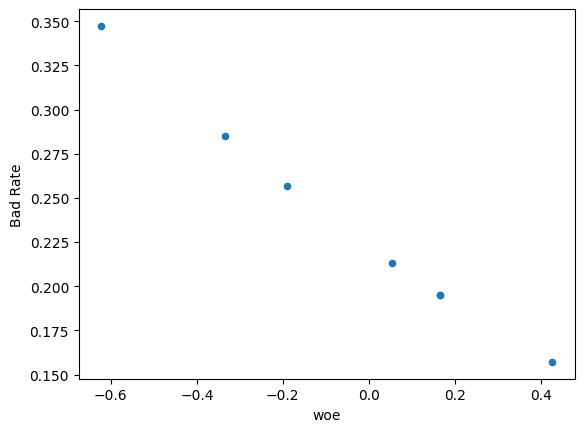

In [146]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [147]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [148]:
merged

,loan_amnt_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.213060,9035,20.077778,500.00 - 4400.00
1,1.0,0.194938,4504,10.008889,4400.00 - 5400.00
2,2.0,0.157140,4461,9.913333,5400.00 - 6600.00
3,3.0,0.194774,15654,34.786667,6600.00 - 12000.00
4,4.0,0.256728,2341,5.202222,12000.00 - 14520.20
5,5.0,0.285335,4521,10.046667,14520.20 - 19200.00
6,6.0,0.347399,4479,9.953333,19200.00 - 35000.00


In [149]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [150]:
merged_final

,loan_amnt_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.213060,9035,20.077778,500.00 - 4400.00,9035,1925,2833.844715,7110,0.213060,4.0,0.203172,0.1925,0.010672,0.053956,0.000576,-1.306576
1,1.0,0.194938,4504,10.008889,4400.00 - 5400.00,4504,878,4935.041519,3626,0.194938,3.0,0.103615,0.0878,0.015815,0.165619,0.002619,-1.418239
2,2.0,0.157140,4461,9.913333,5400.00 - 6600.00,4461,701,6021.494508,3760,0.157140,1.0,0.107444,0.0701,0.037344,0.427046,0.015948,-1.679666
3,3.0,0.194774,15654,34.786667,6600.00 - 12000.00,15654,3049,9384.338188,12605,0.194774,2.0,0.360194,0.3049,0.055294,0.166660,0.009215,-1.419280
4,4.0,0.256728,2341,5.202222,12000.00 - 14520.20,2341,601,13451.021358,1740,0.256728,5.0,0.049721,0.0601,-0.010379,-0.189575,0.001968,-1.063045
5,5.0,0.285335,4521,10.046667,14520.20 - 19200.00,4521,1290,16068.666888,3231,0.285335,6.0,0.092327,0.1290,-0.036673,-0.334471,0.012266,-0.918149
6,6.0,0.347399,4479,9.953333,19200.00 - 35000.00,4479,1556,23556.323956,2923,0.347399,7.0,0.083526,0.1556,-0.072074,-0.622128,0.044839,-0.630492


In [151]:
lstbin

[500.0, 4400.0, 5400.0, 6600.0, 12000.0, 14520.200000000026, 19200.0, 35000.0]

In [152]:
list(merged_final['Value_Range'])

['500.00 - 4400.00',
 '4400.00 - 5400.00',
 '5400.00 - 6600.00',
 '6600.00 - 12000.00',
 '12000.00 - 14520.20',
 '14520.20 - 19200.00',
 '19200.00 - 35000.00']

In [153]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'500.00 - 4400.00': 0.05395617492794456,
 '4400.00 - 5400.00': 0.16561869653222244,
 '5400.00 - 6600.00': 0.4270462482018929,
 '6600.00 - 12000.00': 0.16665979148630822,
 '12000.00 - 14520.20': -0.18957464347409025,
 '14520.20 - 19200.00': -0.33447063267867694,
 '19200.00 - 35000.00': -0.6221280407745482}

## loan_int_rate

In [154]:
var = 'loan_int_rate'

In [155]:
data[var].isna().sum()

np.int64(0)

In [156]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [157]:
init_lstbin = list(bintest)

In [158]:
init_lstbin

[np.float64(5.42),
 np.float64(6.99),
 np.float64(7.88),
 np.float64(9.44),
 np.float64(10.58),
 np.float64(11.01),
 np.float64(11.49),
 np.float64(12.53),
 np.float64(13.49),
 np.float64(14.97),
 np.float64(20.0)]

### Int Bins

In [159]:
lstbin = [5.42, 6.99, 7.88, 9.44, 10.58, 11.01, 11.49, 12.53, 13.49, 14.97, 20.0]


In [160]:
len(data)

45000

In [161]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,loan_int_rate_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.078643,3980,8.844444,5.42 - 6.99
1,1.0,0.096192,4491,9.980000,6.99 - 7.88
2,2.0,0.130111,4427,9.837778,7.88 - 9.44
3,3.0,0.158058,4511,10.024444,9.44 - 10.58
4,4.0,0.181931,6420,14.266667,10.58 - 11.01
5,5.0,0.173787,2762,6.137778,11.01 - 11.49
6,6.0,0.196577,4441,9.868889,11.49 - 12.53
7,7.0,0.228954,4407,9.793333,12.53 - 13.49
8,8.0,0.375617,4454,9.897778,13.49 - 14.97
9,9.0,0.607468,4499,9.997778,14.97 - 20.00


,loan_int_rate
count,45000.000000
mean,11.006606
std,2.978808
min,5.420000
25%,8.590000
50%,11.010000
75%,12.990000
max,20.000000


In [162]:
data[var + '_binned'].nunique()

10

In [163]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [164]:
iv = IV_SupplyBins()

In [165]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,loan_int_rate_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,3980,313,6.406786,3667,0.078643,1.0,0.106531,0.031394,0.075137,1.221811,0.091803
1,1.0,4491,432,7.520477,4059,0.096192,2.0,0.117919,0.043330,0.074589,1.001151,0.074675
2,2.0,4427,576,8.600079,3851,0.130111,3.0,0.111876,0.057773,0.054103,0.660865,0.035755
3,3.0,4511,713,10.034223,3798,0.158058,4.0,0.110336,0.071515,0.038822,0.433633,0.016834
4,4.0,6420,1168,10.907928,5252,0.181931,6.0,0.152577,0.117151,0.035425,0.264201,0.009359
5,5.0,2762,480,11.290413,2282,0.173787,5.0,0.066295,0.048144,0.018150,0.319906,0.005806
6,6.0,4441,873,12.026521,3568,0.196577,7.0,0.103655,0.087563,0.016092,0.168710,0.002715
7,7.0,4407,1009,13.052957,3398,0.228954,8.0,0.098716,0.101204,-0.002488,-0.024888,0.000062
8,8.0,4454,1673,14.242997,2781,0.375617,9.0,0.080791,0.167803,-0.087012,-0.730923,0.063599
9,9.0,4499,2733,16.404981,1766,0.607468,10.0,0.051304,0.274122,-0.222818,-1.675798,0.373398


Information value:  0.6740060225074445


### Modified Bin

In [166]:
len(data)

45000

In [167]:
lstbin = [5.42, 6.99, 7.88, 9.44, 10.58, 11.01, 11.49, 12.53, 13.49, 14.97, 20.0]


In [168]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,loan_int_rate_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.078643,3980,8.844444,5.42 - 6.99
1,1.0,0.096192,4491,9.980000,6.99 - 7.88
2,2.0,0.130111,4427,9.837778,7.88 - 9.44
3,3.0,0.158058,4511,10.024444,9.44 - 10.58
4,4.0,0.181931,6420,14.266667,10.58 - 11.01
5,5.0,0.173787,2762,6.137778,11.01 - 11.49
6,6.0,0.196577,4441,9.868889,11.49 - 12.53
7,7.0,0.228954,4407,9.793333,12.53 - 13.49
8,8.0,0.375617,4454,9.897778,13.49 - 14.97
9,9.0,0.607468,4499,9.997778,14.97 - 20.00


,loan_int_rate
count,45000.000000
mean,11.006606
std,2.978808
min,5.420000
25%,8.590000
50%,11.010000
75%,12.990000
max,20.000000


In [169]:
data[var + '_binned'].nunique()

10

In [170]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [171]:
iv = IV_SupplyBins()

In [172]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,loan_int_rate_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,3980,313,6.406786,3667,0.078643,1.0,0.106531,0.031394,0.075137,1.221811,0.091803
1,1.0,4491,432,7.520477,4059,0.096192,2.0,0.117919,0.043330,0.074589,1.001151,0.074675
2,2.0,4427,576,8.600079,3851,0.130111,3.0,0.111876,0.057773,0.054103,0.660865,0.035755
3,3.0,4511,713,10.034223,3798,0.158058,4.0,0.110336,0.071515,0.038822,0.433633,0.016834
4,4.0,6420,1168,10.907928,5252,0.181931,6.0,0.152577,0.117151,0.035425,0.264201,0.009359
5,5.0,2762,480,11.290413,2282,0.173787,5.0,0.066295,0.048144,0.018150,0.319906,0.005806
6,6.0,4441,873,12.026521,3568,0.196577,7.0,0.103655,0.087563,0.016092,0.168710,0.002715
7,7.0,4407,1009,13.052957,3398,0.228954,8.0,0.098716,0.101204,-0.002488,-0.024888,0.000062
8,8.0,4454,1673,14.242997,2781,0.375617,9.0,0.080791,0.167803,-0.087012,-0.730923,0.063599
9,9.0,4499,2733,16.404981,1766,0.607468,10.0,0.051304,0.274122,-0.222818,-1.675798,0.373398


Information value:  0.6740060225074445


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

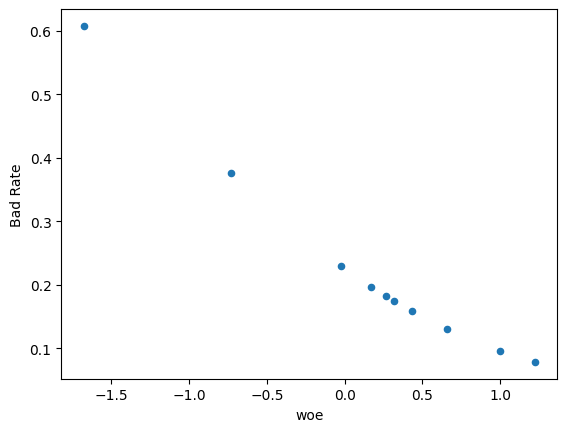

In [173]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [174]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [175]:
merged

,loan_int_rate_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.078643,3980,8.844444,5.42 - 6.99
1,1.0,0.096192,4491,9.980000,6.99 - 7.88
2,2.0,0.130111,4427,9.837778,7.88 - 9.44
3,3.0,0.158058,4511,10.024444,9.44 - 10.58
4,4.0,0.181931,6420,14.266667,10.58 - 11.01
5,5.0,0.173787,2762,6.137778,11.01 - 11.49
6,6.0,0.196577,4441,9.868889,11.49 - 12.53
7,7.0,0.228954,4407,9.793333,12.53 - 13.49
8,8.0,0.375617,4454,9.897778,13.49 - 14.97
9,9.0,0.607468,4499,9.997778,14.97 - 20.00


In [176]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [177]:
merged_final

,loan_int_rate_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.078643,3980,8.844444,5.42 - 6.99,3980,313,6.406786,3667,0.078643,1.0,0.106531,0.031394,0.075137,1.221811,0.091803,-2.460926
1,1.0,0.096192,4491,9.980000,6.99 - 7.88,4491,432,7.520477,4059,0.096192,2.0,0.117919,0.043330,0.074589,1.001151,0.074675,-2.240266
2,2.0,0.130111,4427,9.837778,7.88 - 9.44,4427,576,8.600079,3851,0.130111,3.0,0.111876,0.057773,0.054103,0.660865,0.035755,-1.899980
3,3.0,0.158058,4511,10.024444,9.44 - 10.58,4511,713,10.034223,3798,0.158058,4.0,0.110336,0.071515,0.038822,0.433633,0.016834,-1.672748
4,4.0,0.181931,6420,14.266667,10.58 - 11.01,6420,1168,10.907928,5252,0.181931,6.0,0.152577,0.117151,0.035425,0.264201,0.009359,-1.503316
5,5.0,0.173787,2762,6.137778,11.01 - 11.49,2762,480,11.290413,2282,0.173787,5.0,0.066295,0.048144,0.018150,0.319906,0.005806,-1.559021
6,6.0,0.196577,4441,9.868889,11.49 - 12.53,4441,873,12.026521,3568,0.196577,7.0,0.103655,0.087563,0.016092,0.168710,0.002715,-1.407825
7,7.0,0.228954,4407,9.793333,12.53 - 13.49,4407,1009,13.052957,3398,0.228954,8.0,0.098716,0.101204,-0.002488,-0.024888,0.000062,-1.214227
8,8.0,0.375617,4454,9.897778,13.49 - 14.97,4454,1673,14.242997,2781,0.375617,9.0,0.080791,0.167803,-0.087012,-0.730923,0.063599,-0.508192
9,9.0,0.607468,4499,9.997778,14.97 - 20.00,4499,2733,16.404981,1766,0.607468,10.0,0.051304,0.274122,-0.222818,-1.675798,0.373398,0.436683


In [178]:
lstbin

[5.42, 6.99, 7.88, 9.44, 10.58, 11.01, 11.49, 12.53, 13.49, 14.97, 20.0]

In [179]:
list(merged_final['Value_Range'])

['5.42 - 6.99',
 '6.99 - 7.88',
 '7.88 - 9.44',
 '9.44 - 10.58',
 '10.58 - 11.01',
 '11.01 - 11.49',
 '11.49 - 12.53',
 '12.53 - 13.49',
 '13.49 - 14.97',
 '14.97 - 20.00']

In [180]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'5.42 - 6.99': 1.2218106666571307,
 '6.99 - 7.88': 1.0011510177207454,
 '7.88 - 9.44': 0.6608651622449755,
 '9.44 - 10.58': 0.43363316008389324,
 '10.58 - 11.01': 0.26420076116047225,
 '11.01 - 11.49': 0.31990611564604227,
 '11.49 - 12.53': 0.16870962698625566,
 '12.53 - 13.49': -0.024888028995773536,
 '13.49 - 14.97': -0.730923157626901,
 '14.97 - 20.00': -1.6757981156382047}

## loan_percent_income

In [181]:
var = 'loan_percent_income'

In [182]:
data[var].isna().sum()

np.int64(0)

In [183]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [184]:
init_lstbin = list(bintest)

In [185]:
init_lstbin

[np.float64(0.0),
 np.float64(0.04),
 np.float64(0.06),
 np.float64(0.08),
 np.float64(0.1),
 np.float64(0.12),
 np.float64(0.14),
 np.float64(0.17),
 np.float64(0.21),
 np.float64(0.26),
 np.float64(0.66)]

### Int Bins

In [186]:
lstbin = [0.0, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.17, 0.21, 0.26, 0.66]



In [187]:
len(data)

45000

In [188]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,loan_percent_income_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.101128,4697,10.437778,0.00 - 0.04
1,1.0,0.117927,4418,9.817778,0.04 - 0.06
2,2.0,0.129193,5008,11.128889,0.06 - 0.08
3,3.0,0.122986,4716,10.480000,0.08 - 0.10
4,4.0,0.139689,4374,9.720000,0.10 - 0.12
5,5.0,0.176744,3870,8.600000,0.12 - 0.14
6,6.0,0.186905,4933,10.962222,0.14 - 0.17
7,7.0,0.213940,4749,10.553333,0.17 - 0.21
8,8.0,0.375458,3822,8.493333,0.21 - 0.26
9,9.0,0.708618,4386,9.746667,0.26 - 0.66


,loan_percent_income
count,45000.000000
mean,0.139725
std,0.087212
min,0.000000
25%,0.070000
50%,0.120000
75%,0.190000
max,0.660000


In [189]:
data[var + '_binned'].nunique()

10

In [190]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [191]:
iv = IV_SupplyBins()

In [192]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,loan_percent_income_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4697,475,0.030801,4222,0.101128,1.0,0.120718,0.047505,0.073213,0.932630,0.068281
1,1.0,4418,521,0.055075,3897,0.117927,2.0,0.111426,0.052105,0.059320,0.760092,0.045089
2,2.0,5008,647,0.075178,4361,0.129193,4.0,0.124693,0.064706,0.059986,0.655991,0.039350
3,3.0,4716,580,0.095134,4136,0.122986,3.0,0.118259,0.058006,0.060253,0.712336,0.042921
4,4.0,4374,611,0.115066,3763,0.139689,5.0,0.107594,0.061106,0.046488,0.565755,0.026301
5,5.0,3870,684,0.135065,3186,0.176744,6.0,0.091096,0.068407,0.022689,0.286444,0.006499
6,6.0,4933,922,0.159359,4011,0.186905,7.0,0.114685,0.092209,0.022476,0.218131,0.004903
7,7.0,4749,1016,0.194013,3733,0.213940,8.0,0.106736,0.101610,0.005126,0.049219,0.000252
8,8.0,3822,1435,0.238176,2387,0.375458,9.0,0.068251,0.143514,-0.075264,-0.743247,0.055940
9,9.0,4386,3108,0.326195,1278,0.708618,10.0,0.036541,0.310831,-0.274290,-2.140803,0.587200


Information value:  0.8767358984136884


### Modified Bin

In [193]:
len(data)

45000

In [194]:
lstbin = [0.0, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.17, 0.21, 0.26, 0.66]



In [195]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,loan_percent_income_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.101128,4697,10.437778,0.00 - 0.04
1,1.0,0.117927,4418,9.817778,0.04 - 0.06
2,2.0,0.129193,5008,11.128889,0.06 - 0.08
3,3.0,0.122986,4716,10.480000,0.08 - 0.10
4,4.0,0.139689,4374,9.720000,0.10 - 0.12
5,5.0,0.176744,3870,8.600000,0.12 - 0.14
6,6.0,0.186905,4933,10.962222,0.14 - 0.17
7,7.0,0.213940,4749,10.553333,0.17 - 0.21
8,8.0,0.375458,3822,8.493333,0.21 - 0.26
9,9.0,0.708618,4386,9.746667,0.26 - 0.66


,loan_percent_income
count,45000.000000
mean,0.139725
std,0.087212
min,0.000000
25%,0.070000
50%,0.120000
75%,0.190000
max,0.660000


In [196]:
data[var + '_binned'].nunique()

10

In [197]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [198]:
iv = IV_SupplyBins()

In [199]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,loan_percent_income_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4697,475,0.030801,4222,0.101128,1.0,0.120718,0.047505,0.073213,0.932630,0.068281
1,1.0,4418,521,0.055075,3897,0.117927,2.0,0.111426,0.052105,0.059320,0.760092,0.045089
2,2.0,5008,647,0.075178,4361,0.129193,4.0,0.124693,0.064706,0.059986,0.655991,0.039350
3,3.0,4716,580,0.095134,4136,0.122986,3.0,0.118259,0.058006,0.060253,0.712336,0.042921
4,4.0,4374,611,0.115066,3763,0.139689,5.0,0.107594,0.061106,0.046488,0.565755,0.026301
5,5.0,3870,684,0.135065,3186,0.176744,6.0,0.091096,0.068407,0.022689,0.286444,0.006499
6,6.0,4933,922,0.159359,4011,0.186905,7.0,0.114685,0.092209,0.022476,0.218131,0.004903
7,7.0,4749,1016,0.194013,3733,0.213940,8.0,0.106736,0.101610,0.005126,0.049219,0.000252
8,8.0,3822,1435,0.238176,2387,0.375458,9.0,0.068251,0.143514,-0.075264,-0.743247,0.055940
9,9.0,4386,3108,0.326195,1278,0.708618,10.0,0.036541,0.310831,-0.274290,-2.140803,0.587200


Information value:  0.8767358984136884


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

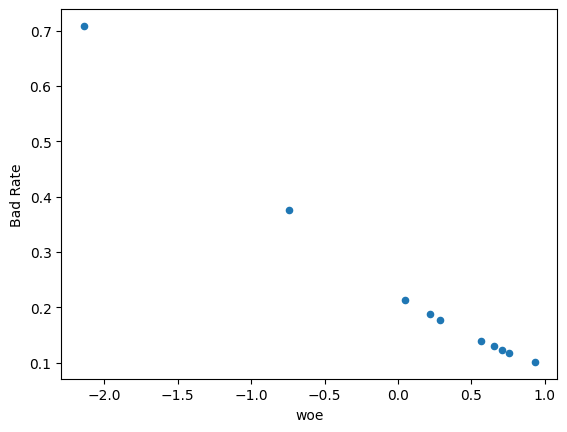

In [200]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [201]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [202]:
merged

,loan_percent_income_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.101128,4697,10.437778,0.00 - 0.04
1,1.0,0.117927,4418,9.817778,0.04 - 0.06
2,2.0,0.129193,5008,11.128889,0.06 - 0.08
3,3.0,0.122986,4716,10.480000,0.08 - 0.10
4,4.0,0.139689,4374,9.720000,0.10 - 0.12
5,5.0,0.176744,3870,8.600000,0.12 - 0.14
6,6.0,0.186905,4933,10.962222,0.14 - 0.17
7,7.0,0.213940,4749,10.553333,0.17 - 0.21
8,8.0,0.375458,3822,8.493333,0.21 - 0.26
9,9.0,0.708618,4386,9.746667,0.26 - 0.66


In [203]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [204]:
merged_final

,loan_percent_income_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.101128,4697,10.437778,0.00 - 0.04,4697,475,0.030801,4222,0.101128,1.0,0.120718,0.047505,0.073213,0.932630,0.068281,-2.184749
1,1.0,0.117927,4418,9.817778,0.04 - 0.06,4418,521,0.055075,3897,0.117927,2.0,0.111426,0.052105,0.059320,0.760092,0.045089,-2.012212
2,2.0,0.129193,5008,11.128889,0.06 - 0.08,5008,647,0.075178,4361,0.129193,4.0,0.124693,0.064706,0.059986,0.655991,0.039350,-1.908110
3,3.0,0.122986,4716,10.480000,0.08 - 0.10,4716,580,0.095134,4136,0.122986,3.0,0.118259,0.058006,0.060253,0.712336,0.042921,-1.964456
4,4.0,0.139689,4374,9.720000,0.10 - 0.12,4374,611,0.115066,3763,0.139689,5.0,0.107594,0.061106,0.046488,0.565755,0.026301,-1.817875
5,5.0,0.176744,3870,8.600000,0.12 - 0.14,3870,684,0.135065,3186,0.176744,6.0,0.091096,0.068407,0.022689,0.286444,0.006499,-1.538564
6,6.0,0.186905,4933,10.962222,0.14 - 0.17,4933,922,0.159359,4011,0.186905,7.0,0.114685,0.092209,0.022476,0.218131,0.004903,-1.470251
7,7.0,0.213940,4749,10.553333,0.17 - 0.21,4749,1016,0.194013,3733,0.213940,8.0,0.106736,0.101610,0.005126,0.049219,0.000252,-1.301339
8,8.0,0.375458,3822,8.493333,0.21 - 0.26,3822,1435,0.238176,2387,0.375458,9.0,0.068251,0.143514,-0.075264,-0.743247,0.055940,-0.508872
9,9.0,0.708618,4386,9.746667,0.26 - 0.66,4386,3108,0.326195,1278,0.708618,10.0,0.036541,0.310831,-0.274290,-2.140803,0.587200,0.888683


In [205]:
lstbin

[0.0, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.17, 0.21, 0.26, 0.66]

In [206]:
list(merged_final['Value_Range'])

['0.00 - 0.04',
 '0.04 - 0.06',
 '0.06 - 0.08',
 '0.08 - 0.10',
 '0.10 - 0.12',
 '0.12 - 0.14',
 '0.14 - 0.17',
 '0.17 - 0.21',
 '0.21 - 0.26',
 '0.26 - 0.66']

In [207]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'0.00 - 0.04': 0.9326295840758693,
 '0.04 - 0.06': 0.7600924232875869,
 '0.06 - 0.08': 0.6559905330441104,
 '0.08 - 0.10': 0.7123364723500446,
 '0.10 - 0.12': 0.5657549911240866,
 '0.12 - 0.14': 0.2864437325496879,
 '0.14 - 0.17': 0.21813080191570366,
 '0.17 - 0.21': 0.04921901047840122,
 '0.21 - 0.26': -0.7432473421526467,
 '0.26 - 0.66': -2.140802916847813}

## cb_person_cred_hist_length

In [208]:
var = 'cb_person_cred_hist_length'

In [209]:
data[var].isna().sum()

np.int64(0)

In [210]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [211]:
init_lstbin = list(bintest)

In [212]:
init_lstbin

[np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(9.0),
 np.float64(11.0),
 np.float64(30.0)]

### Int Bins

In [213]:
lstbin = [2.0, 3.0, 4.0, 6.0, 7.0, 9.0, 11.0, 30.0]


In [214]:
len(data)

45000

In [215]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,cb_person_cred_hist_length_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227743,8312,18.471111,2.00 - 3.00
1,1.0,0.225587,8653,19.228889,3.00 - 4.00
2,2.0,0.216766,6048,13.440000,4.00 - 6.00
3,3.0,0.221184,2889,6.420000,6.00 - 7.00
4,4.0,0.212033,5485,12.188889,7.00 - 9.00
5,5.0,0.207005,3169,7.042222,9.00 - 11.00
6,6.0,0.213719,3907,8.682222,11.00 - 30.00


,cb_person_cred_hist_length
count,45000.000000
mean,5.867489
std,3.879702
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


In [216]:
data[var + '_binned'].nunique()

7

In [217]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [218]:
iv = IV_SupplyBins()

In [219]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,cb_person_cred_hist_length_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,8312,1893,3.000000,6419,0.227743,7.0,0.213867,0.224050,-0.010183,-0.046516,0.000474
1,1.0,8653,1952,4.000000,6701,0.225587,6.0,0.223262,0.231033,-0.007771,-0.034214,0.000266
2,2.0,6048,1311,5.490410,4737,0.216766,4.0,0.157826,0.155166,0.002660,0.016998,0.000045
3,3.0,2889,639,7.000000,2250,0.221184,5.0,0.074965,0.075630,-0.000665,-0.008835,0.000006
4,4.0,5485,1163,8.489517,4322,0.212033,2.0,0.143999,0.137649,0.006350,0.045100,0.000286
5,5.0,3169,656,10.224677,2513,0.207005,1.0,0.083728,0.077642,0.006085,0.075456,0.000459
6,6.0,3907,835,15.105964,3072,0.213719,3.0,0.102352,0.098828,0.003524,0.035037,0.000123


Information value:  0.001659671230323708


### Modified Bin

In [220]:
len(data)

45000

In [221]:
lstbin = [2.0, 3.0, 4.0, 6.0, 7.0, 9.0, 11.0, 30.0]


In [222]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,cb_person_cred_hist_length_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227743,8312,18.471111,2.00 - 3.00
1,1.0,0.225587,8653,19.228889,3.00 - 4.00
2,2.0,0.216766,6048,13.440000,4.00 - 6.00
3,3.0,0.221184,2889,6.420000,6.00 - 7.00
4,4.0,0.212033,5485,12.188889,7.00 - 9.00
5,5.0,0.207005,3169,7.042222,9.00 - 11.00
6,6.0,0.213719,3907,8.682222,11.00 - 30.00


,cb_person_cred_hist_length
count,45000.000000
mean,5.867489
std,3.879702
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


In [223]:
data[var + '_binned'].nunique()

7

In [224]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [225]:
iv = IV_SupplyBins()

In [226]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,cb_person_cred_hist_length_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,8312,1893,3.000000,6419,0.227743,7.0,0.213867,0.224050,-0.010183,-0.046516,0.000474
1,1.0,8653,1952,4.000000,6701,0.225587,6.0,0.223262,0.231033,-0.007771,-0.034214,0.000266
2,2.0,6048,1311,5.490410,4737,0.216766,4.0,0.157826,0.155166,0.002660,0.016998,0.000045
3,3.0,2889,639,7.000000,2250,0.221184,5.0,0.074965,0.075630,-0.000665,-0.008835,0.000006
4,4.0,5485,1163,8.489517,4322,0.212033,2.0,0.143999,0.137649,0.006350,0.045100,0.000286
5,5.0,3169,656,10.224677,2513,0.207005,1.0,0.083728,0.077642,0.006085,0.075456,0.000459
6,6.0,3907,835,15.105964,3072,0.213719,3.0,0.102352,0.098828,0.003524,0.035037,0.000123


Information value:  0.001659671230323708


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

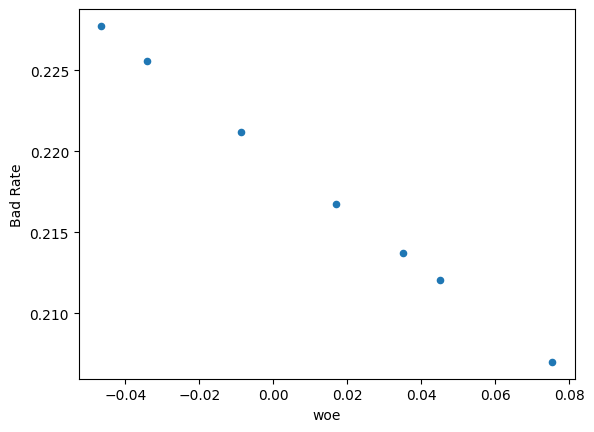

In [227]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [228]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [229]:
merged

,cb_person_cred_hist_length_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227743,8312,18.471111,2.00 - 3.00
1,1.0,0.225587,8653,19.228889,3.00 - 4.00
2,2.0,0.216766,6048,13.440000,4.00 - 6.00
3,3.0,0.221184,2889,6.420000,6.00 - 7.00
4,4.0,0.212033,5485,12.188889,7.00 - 9.00
5,5.0,0.207005,3169,7.042222,9.00 - 11.00
6,6.0,0.213719,3907,8.682222,11.00 - 30.00


In [230]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [231]:
merged_final

,cb_person_cred_hist_length_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.227743,8312,18.471111,2.00 - 3.00,8312,1893,3.000000,6419,0.227743,7.0,0.213867,0.224050,-0.010183,-0.046516,0.000474,-1.221099
1,1.0,0.225587,8653,19.228889,3.00 - 4.00,8653,1952,4.000000,6701,0.225587,6.0,0.223262,0.231033,-0.007771,-0.034214,0.000266,-1.233402
2,2.0,0.216766,6048,13.440000,4.00 - 6.00,6048,1311,5.490410,4737,0.216766,4.0,0.157826,0.155166,0.002660,0.016998,0.000045,-1.284614
3,3.0,0.221184,2889,6.420000,6.00 - 7.00,2889,639,7.000000,2250,0.221184,5.0,0.074965,0.075630,-0.000665,-0.008835,0.000006,-1.258781
4,4.0,0.212033,5485,12.188889,7.00 - 9.00,5485,1163,8.489517,4322,0.212033,2.0,0.143999,0.137649,0.006350,0.045100,0.000286,-1.312715
5,5.0,0.207005,3169,7.042222,9.00 - 11.00,3169,656,10.224677,2513,0.207005,1.0,0.083728,0.077642,0.006085,0.075456,0.000459,-1.343072
6,6.0,0.213719,3907,8.682222,11.00 - 30.00,3907,835,15.105964,3072,0.213719,3.0,0.102352,0.098828,0.003524,0.035037,0.000123,-1.302652


In [232]:
lstbin

[2.0, 3.0, 4.0, 6.0, 7.0, 9.0, 11.0, 30.0]

In [233]:
list(merged_final['Value_Range'])

['2.00 - 3.00',
 '3.00 - 4.00',
 '4.00 - 6.00',
 '6.00 - 7.00',
 '7.00 - 9.00',
 '9.00 - 11.00',
 '11.00 - 30.00']

In [234]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'2.00 - 3.00': -0.0465163782006347,
 '3.00 - 4.00': -0.03421356730295714,
 '4.00 - 6.00': 0.016997970856961905,
 '6.00 - 7.00': -0.008834807482158912,
 '7.00 - 9.00': 0.045099536245076746,
 '9.00 - 11.00': 0.07545590029641308,
 '11.00 - 30.00': 0.035036521113617096}

## credit_score

In [235]:
var = 'credit_score'

In [236]:
data[var].isna().sum()

np.int64(0)

In [237]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [238]:
init_lstbin = list(bintest)

In [239]:
init_lstbin

[np.float64(390.0),
 np.float64(563.0),
 np.float64(591.0),
 np.float64(611.0),
 np.float64(626.0),
 np.float64(640.0),
 np.float64(652.0),
 np.float64(663.0),
 np.float64(676.0),
 np.float64(692.0),
 np.float64(850.0)]

### Int Bins

In [240]:
lstbin = [390.0, 563.0, 591.0, 611.0, 626.0, 640.0, 652.0, 663.0, 676.0, 692.0, 850.0]



In [241]:
len(data)

45000

In [242]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227511,4580,10.177778,390.00 - 563.00
1,1.0,0.220742,4580,10.177778,563.00 - 591.00
2,2.0,0.230971,4572,10.160000,591.00 - 611.00
3,3.0,0.218219,4358,9.684444,611.00 - 626.00
4,4.0,0.228692,4740,10.533333,626.00 - 640.00
5,5.0,0.218324,4475,9.944444,640.00 - 652.00
6,6.0,0.226527,4207,9.348889,652.00 - 663.00
7,7.0,0.222175,4690,10.422222,663.00 - 676.00
8,8.0,0.219491,4515,10.033333,676.00 - 692.00
9,9.0,0.208547,4282,9.515556,692.00 - 850.00


,credit_score
count,45000.000000
mean,632.608756
std,50.435865
min,390.000000
25%,601.000000
50%,640.000000
75%,670.000000
max,850.000000


In [243]:
data[var + '_binned'].nunique()

10

In [244]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [245]:
iv = IV_SupplyBins()

In [246]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,credit_score_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4580,1042,532.890830,3538,0.227511,8.0,0.101089,0.1042,-0.003111,-0.030315,9.432122e-05
1,1.0,4580,1011,578.687118,3569,0.220742,5.0,0.101974,0.1011,0.000874,0.008611,7.529054e-06
2,2.0,4572,1056,602.038058,3516,0.230971,10.0,0.100460,0.1056,-0.005140,-0.049899,2.564782e-04
3,3.0,4358,951,619.261358,3407,0.218219,2.0,0.097346,0.0951,0.002246,0.023339,5.241086e-05
4,4.0,4740,1084,633.633122,3656,0.228692,9.0,0.104460,0.1084,-0.003940,-0.037023,1.458645e-04
5,5.0,4475,977,646.656313,3498,0.218324,3.0,0.099946,0.0977,0.002246,0.022726,5.103518e-05
6,6.0,4207,953,657.987402,3254,0.226527,7.0,0.092974,0.0953,-0.002326,-0.024709,5.747106e-05
7,7.0,4690,1042,669.977825,3648,0.222175,6.0,0.104232,0.1042,0.000032,0.000303,9.551042e-09
8,8.0,4515,991,684.042968,3524,0.219491,4.0,0.100689,0.0991,0.001589,0.015903,2.526345e-05
9,9.0,4282,893,707.311303,3389,0.208547,1.0,0.096831,0.0893,0.007531,0.080969,6.098064e-04


Information value:  0.001300189425952615


### Modified Bin

In [247]:
len(data)

45000

In [248]:
lstbin = [390.0, 563.0, 591.0, 611.0, 626.0, 640.0, 652.0, 663.0, 676.0, 692.0, 850.0]



In [249]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227511,4580,10.177778,390.00 - 563.00
1,1.0,0.220742,4580,10.177778,563.00 - 591.00
2,2.0,0.230971,4572,10.160000,591.00 - 611.00
3,3.0,0.218219,4358,9.684444,611.00 - 626.00
4,4.0,0.228692,4740,10.533333,626.00 - 640.00
5,5.0,0.218324,4475,9.944444,640.00 - 652.00
6,6.0,0.226527,4207,9.348889,652.00 - 663.00
7,7.0,0.222175,4690,10.422222,663.00 - 676.00
8,8.0,0.219491,4515,10.033333,676.00 - 692.00
9,9.0,0.208547,4282,9.515556,692.00 - 850.00


,credit_score
count,45000.000000
mean,632.608756
std,50.435865
min,390.000000
25%,601.000000
50%,640.000000
75%,670.000000
max,850.000000


In [250]:
data[var + '_binned'].nunique()

10

In [251]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [252]:
iv = IV_SupplyBins()

In [253]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,credit_score_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4580,1042,532.890830,3538,0.227511,8.0,0.101089,0.1042,-0.003111,-0.030315,9.432122e-05
1,1.0,4580,1011,578.687118,3569,0.220742,5.0,0.101974,0.1011,0.000874,0.008611,7.529054e-06
2,2.0,4572,1056,602.038058,3516,0.230971,10.0,0.100460,0.1056,-0.005140,-0.049899,2.564782e-04
3,3.0,4358,951,619.261358,3407,0.218219,2.0,0.097346,0.0951,0.002246,0.023339,5.241086e-05
4,4.0,4740,1084,633.633122,3656,0.228692,9.0,0.104460,0.1084,-0.003940,-0.037023,1.458645e-04
5,5.0,4475,977,646.656313,3498,0.218324,3.0,0.099946,0.0977,0.002246,0.022726,5.103518e-05
6,6.0,4207,953,657.987402,3254,0.226527,7.0,0.092974,0.0953,-0.002326,-0.024709,5.747106e-05
7,7.0,4690,1042,669.977825,3648,0.222175,6.0,0.104232,0.1042,0.000032,0.000303,9.551042e-09
8,8.0,4515,991,684.042968,3524,0.219491,4.0,0.100689,0.0991,0.001589,0.015903,2.526345e-05
9,9.0,4282,893,707.311303,3389,0.208547,1.0,0.096831,0.0893,0.007531,0.080969,6.098064e-04


Information value:  0.001300189425952615


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

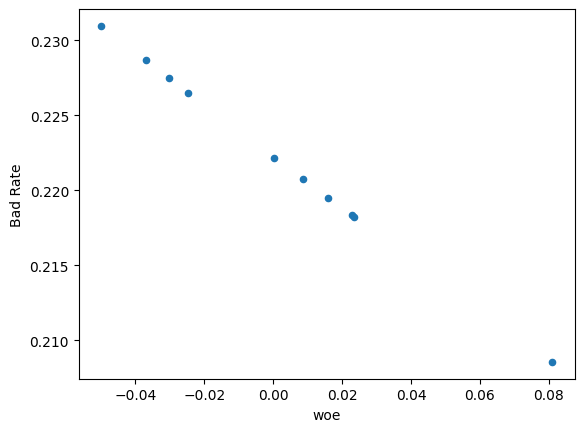

In [254]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [255]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [256]:
merged

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227511,4580,10.177778,390.00 - 563.00
1,1.0,0.220742,4580,10.177778,563.00 - 591.00
2,2.0,0.230971,4572,10.160000,591.00 - 611.00
3,3.0,0.218219,4358,9.684444,611.00 - 626.00
4,4.0,0.228692,4740,10.533333,626.00 - 640.00
5,5.0,0.218324,4475,9.944444,640.00 - 652.00
6,6.0,0.226527,4207,9.348889,652.00 - 663.00
7,7.0,0.222175,4690,10.422222,663.00 - 676.00
8,8.0,0.219491,4515,10.033333,676.00 - 692.00
9,9.0,0.208547,4282,9.515556,692.00 - 850.00


In [257]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [258]:
merged_final

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.227511,4580,10.177778,390.00 - 563.00,4580,1042,532.890830,3538,0.227511,8.0,0.101089,0.1042,-0.003111,-0.030315,9.432122e-05,-1.222420
1,1.0,0.220742,4580,10.177778,563.00 - 591.00,4580,1011,578.687118,3569,0.220742,5.0,0.101974,0.1011,0.000874,0.008611,7.529054e-06,-1.261346
2,2.0,0.230971,4572,10.160000,591.00 - 611.00,4572,1056,602.038058,3516,0.230971,10.0,0.100460,0.1056,-0.005140,-0.049899,2.564782e-04,-1.202836
3,3.0,0.218219,4358,9.684444,611.00 - 626.00,4358,951,619.261358,3407,0.218219,2.0,0.097346,0.0951,0.002246,0.023339,5.241086e-05,-1.276073
4,4.0,0.228692,4740,10.533333,626.00 - 640.00,4740,1084,633.633122,3656,0.228692,9.0,0.104460,0.1084,-0.003940,-0.037023,1.458645e-04,-1.215712
5,5.0,0.218324,4475,9.944444,640.00 - 652.00,4475,977,646.656313,3498,0.218324,3.0,0.099946,0.0977,0.002246,0.022726,5.103518e-05,-1.275460
6,6.0,0.226527,4207,9.348889,652.00 - 663.00,4207,953,657.987402,3254,0.226527,7.0,0.092974,0.0953,-0.002326,-0.024709,5.747106e-05,-1.228025
7,7.0,0.222175,4690,10.422222,663.00 - 676.00,4690,1042,669.977825,3648,0.222175,6.0,0.104232,0.1042,0.000032,0.000303,9.551042e-09,-1.253037
8,8.0,0.219491,4515,10.033333,676.00 - 692.00,4515,991,684.042968,3524,0.219491,4.0,0.100689,0.0991,0.001589,0.015903,2.526345e-05,-1.268637
9,9.0,0.208547,4282,9.515556,692.00 - 850.00,4282,893,707.311303,3389,0.208547,1.0,0.096831,0.0893,0.007531,0.080969,6.098064e-04,-1.333704


In [259]:
lstbin

[390.0, 563.0, 591.0, 611.0, 626.0, 640.0, 652.0, 663.0, 676.0, 692.0, 850.0]

In [260]:
list(merged_final['Value_Range'])

['390.00 - 563.00',
 '563.00 - 591.00',
 '591.00 - 611.00',
 '611.00 - 626.00',
 '626.00 - 640.00',
 '640.00 - 652.00',
 '652.00 - 663.00',
 '663.00 - 676.00',
 '676.00 - 692.00',
 '692.00 - 850.00']

In [261]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'390.00 - 563.00': -0.030314744252207218,
 '563.00 - 591.00': 0.008611107811063553,
 '591.00 - 611.00': -0.049898602119764664,
 '611.00 - 626.00': 0.02333895845695071,
 '626.00 - 640.00': -0.03702264608417643,
 '640.00 - 652.00': 0.022725606877138996,
 '652.00 - 663.00': -0.024709012533844495,
 '663.00 - 676.00': 0.0003027322222841338,
 '676.00 - 692.00': 0.01590305606745671,
 '692.00 - 850.00': 0.08096919407192675}

## credit_score

In [262]:
var = 'credit_score'

In [263]:
data[var].isna().sum()

np.int64(0)

In [264]:
_, bintest = pd.qcut(data[var], 10, labels=False, retbins=True,  duplicates='drop') # to get initial bins

In [265]:
init_lstbin = list(bintest)

In [266]:
init_lstbin

[np.float64(390.0),
 np.float64(563.0),
 np.float64(591.0),
 np.float64(611.0),
 np.float64(626.0),
 np.float64(640.0),
 np.float64(652.0),
 np.float64(663.0),
 np.float64(676.0),
 np.float64(692.0),
 np.float64(850.0)]

### Int Bins

In [267]:
lstbin = [390.0, 563.0, 591.0, 611.0, 626.0, 640.0, 652.0, 663.0, 676.0, 692.0, 850.0]



In [268]:
len(data)

45000

In [269]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227511,4580,10.177778,390.00 - 563.00
1,1.0,0.220742,4580,10.177778,563.00 - 591.00
2,2.0,0.230971,4572,10.160000,591.00 - 611.00
3,3.0,0.218219,4358,9.684444,611.00 - 626.00
4,4.0,0.228692,4740,10.533333,626.00 - 640.00
5,5.0,0.218324,4475,9.944444,640.00 - 652.00
6,6.0,0.226527,4207,9.348889,652.00 - 663.00
7,7.0,0.222175,4690,10.422222,663.00 - 676.00
8,8.0,0.219491,4515,10.033333,676.00 - 692.00
9,9.0,0.208547,4282,9.515556,692.00 - 850.00


,credit_score
count,45000.000000
mean,632.608756
std,50.435865
min,390.000000
25%,601.000000
50%,640.000000
75%,670.000000
max,850.000000


In [270]:
data[var + '_binned'].nunique()

10

In [271]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [272]:
iv = IV_SupplyBins()

In [273]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,credit_score_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4580,1042,532.890830,3538,0.227511,8.0,0.101089,0.1042,-0.003111,-0.030315,9.432122e-05
1,1.0,4580,1011,578.687118,3569,0.220742,5.0,0.101974,0.1011,0.000874,0.008611,7.529054e-06
2,2.0,4572,1056,602.038058,3516,0.230971,10.0,0.100460,0.1056,-0.005140,-0.049899,2.564782e-04
3,3.0,4358,951,619.261358,3407,0.218219,2.0,0.097346,0.0951,0.002246,0.023339,5.241086e-05
4,4.0,4740,1084,633.633122,3656,0.228692,9.0,0.104460,0.1084,-0.003940,-0.037023,1.458645e-04
5,5.0,4475,977,646.656313,3498,0.218324,3.0,0.099946,0.0977,0.002246,0.022726,5.103518e-05
6,6.0,4207,953,657.987402,3254,0.226527,7.0,0.092974,0.0953,-0.002326,-0.024709,5.747106e-05
7,7.0,4690,1042,669.977825,3648,0.222175,6.0,0.104232,0.1042,0.000032,0.000303,9.551042e-09
8,8.0,4515,991,684.042968,3524,0.219491,4.0,0.100689,0.0991,0.001589,0.015903,2.526345e-05
9,9.0,4282,893,707.311303,3389,0.208547,1.0,0.096831,0.0893,0.007531,0.080969,6.098064e-04


Information value:  0.001300189425952615


### Modified Bin

In [274]:
len(data)

45000

In [275]:
lstbin = [390.0, 563.0, 591.0, 611.0, 626.0, 640.0, 652.0, 663.0, 676.0, 692.0, 850.0]



In [276]:
merged = plot_bad_rate_num_updated(data, var, lstbin)

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227511,4580,10.177778,390.00 - 563.00
1,1.0,0.220742,4580,10.177778,563.00 - 591.00
2,2.0,0.230971,4572,10.160000,591.00 - 611.00
3,3.0,0.218219,4358,9.684444,611.00 - 626.00
4,4.0,0.228692,4740,10.533333,626.00 - 640.00
5,5.0,0.218324,4475,9.944444,640.00 - 652.00
6,6.0,0.226527,4207,9.348889,652.00 - 663.00
7,7.0,0.222175,4690,10.422222,663.00 - 676.00
8,8.0,0.219491,4515,10.033333,676.00 - 692.00
9,9.0,0.208547,4282,9.515556,692.00 - 850.00


,credit_score
count,45000.000000
mean,632.608756
std,50.435865
min,390.000000
25%,601.000000
50%,640.000000
75%,670.000000
max,850.000000


In [277]:
data[var + '_binned'].nunique()

10

In [278]:
feat_cat_supbins = CategoricalFeature_SupplyBins(data, var + '_binned', 'loan_status', var)

In [279]:
iv = IV_SupplyBins()

In [280]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,credit_score_binned,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,0.0,4580,1042,532.890830,3538,0.227511,8.0,0.101089,0.1042,-0.003111,-0.030315,9.432122e-05
1,1.0,4580,1011,578.687118,3569,0.220742,5.0,0.101974,0.1011,0.000874,0.008611,7.529054e-06
2,2.0,4572,1056,602.038058,3516,0.230971,10.0,0.100460,0.1056,-0.005140,-0.049899,2.564782e-04
3,3.0,4358,951,619.261358,3407,0.218219,2.0,0.097346,0.0951,0.002246,0.023339,5.241086e-05
4,4.0,4740,1084,633.633122,3656,0.228692,9.0,0.104460,0.1084,-0.003940,-0.037023,1.458645e-04
5,5.0,4475,977,646.656313,3498,0.218324,3.0,0.099946,0.0977,0.002246,0.022726,5.103518e-05
6,6.0,4207,953,657.987402,3254,0.226527,7.0,0.092974,0.0953,-0.002326,-0.024709,5.747106e-05
7,7.0,4690,1042,669.977825,3648,0.222175,6.0,0.104232,0.1042,0.000032,0.000303,9.551042e-09
8,8.0,4515,991,684.042968,3524,0.219491,4.0,0.100689,0.0991,0.001589,0.015903,2.526345e-05
9,9.0,4282,893,707.311303,3389,0.208547,1.0,0.096831,0.0893,0.007531,0.080969,6.098064e-04


Information value:  0.001300189425952615


### modified_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

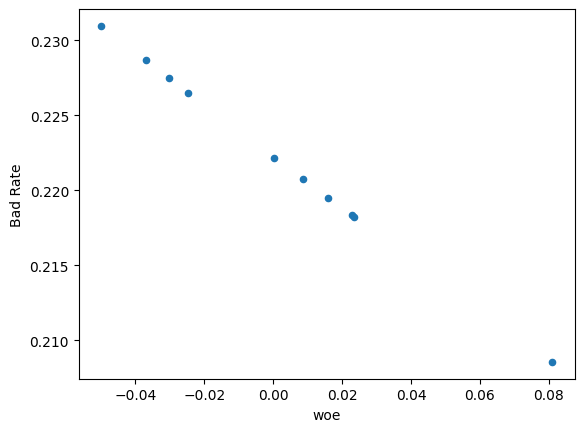

In [281]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [282]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [283]:
merged

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range
0,0.0,0.227511,4580,10.177778,390.00 - 563.00
1,1.0,0.220742,4580,10.177778,563.00 - 591.00
2,2.0,0.230971,4572,10.160000,591.00 - 611.00
3,3.0,0.218219,4358,9.684444,611.00 - 626.00
4,4.0,0.228692,4740,10.533333,626.00 - 640.00
5,5.0,0.218324,4475,9.944444,640.00 - 652.00
6,6.0,0.226527,4207,9.348889,652.00 - 663.00
7,7.0,0.222175,4690,10.422222,663.00 - 676.00
8,8.0,0.219491,4515,10.033333,676.00 - 692.00
9,9.0,0.208547,4282,9.515556,692.00 - 850.00


In [284]:
merged_final = merged.merge(iv_df, on = var + '_binned', how = 'left')

In [285]:
merged_final

,credit_score_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,mean,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,0.0,0.227511,4580,10.177778,390.00 - 563.00,4580,1042,532.890830,3538,0.227511,8.0,0.101089,0.1042,-0.003111,-0.030315,9.432122e-05,-1.222420
1,1.0,0.220742,4580,10.177778,563.00 - 591.00,4580,1011,578.687118,3569,0.220742,5.0,0.101974,0.1011,0.000874,0.008611,7.529054e-06,-1.261346
2,2.0,0.230971,4572,10.160000,591.00 - 611.00,4572,1056,602.038058,3516,0.230971,10.0,0.100460,0.1056,-0.005140,-0.049899,2.564782e-04,-1.202836
3,3.0,0.218219,4358,9.684444,611.00 - 626.00,4358,951,619.261358,3407,0.218219,2.0,0.097346,0.0951,0.002246,0.023339,5.241086e-05,-1.276073
4,4.0,0.228692,4740,10.533333,626.00 - 640.00,4740,1084,633.633122,3656,0.228692,9.0,0.104460,0.1084,-0.003940,-0.037023,1.458645e-04,-1.215712
5,5.0,0.218324,4475,9.944444,640.00 - 652.00,4475,977,646.656313,3498,0.218324,3.0,0.099946,0.0977,0.002246,0.022726,5.103518e-05,-1.275460
6,6.0,0.226527,4207,9.348889,652.00 - 663.00,4207,953,657.987402,3254,0.226527,7.0,0.092974,0.0953,-0.002326,-0.024709,5.747106e-05,-1.228025
7,7.0,0.222175,4690,10.422222,663.00 - 676.00,4690,1042,669.977825,3648,0.222175,6.0,0.104232,0.1042,0.000032,0.000303,9.551042e-09,-1.253037
8,8.0,0.219491,4515,10.033333,676.00 - 692.00,4515,991,684.042968,3524,0.219491,4.0,0.100689,0.0991,0.001589,0.015903,2.526345e-05,-1.268637
9,9.0,0.208547,4282,9.515556,692.00 - 850.00,4282,893,707.311303,3389,0.208547,1.0,0.096831,0.0893,0.007531,0.080969,6.098064e-04,-1.333704


In [286]:
lstbin

[390.0, 563.0, 591.0, 611.0, 626.0, 640.0, 652.0, 663.0, 676.0, 692.0, 850.0]

In [287]:
list(merged_final['Value_Range'])

['390.00 - 563.00',
 '563.00 - 591.00',
 '591.00 - 611.00',
 '611.00 - 626.00',
 '626.00 - 640.00',
 '640.00 - 652.00',
 '652.00 - 663.00',
 '663.00 - 676.00',
 '676.00 - 692.00',
 '692.00 - 850.00']

In [288]:
dict(zip(merged_final['Value_Range'],merged_final['woe']))

{'390.00 - 563.00': -0.030314744252207218,
 '563.00 - 591.00': 0.008611107811063553,
 '591.00 - 611.00': -0.049898602119764664,
 '611.00 - 626.00': 0.02333895845695071,
 '626.00 - 640.00': -0.03702264608417643,
 '640.00 - 652.00': 0.022725606877138996,
 '652.00 - 663.00': -0.024709012533844495,
 '663.00 - 676.00': 0.0003027322222841338,
 '676.00 - 692.00': 0.01590305606745671,
 '692.00 - 850.00': 0.08096919407192675}

#person_home_ownership

In [289]:
var = 'person_home_ownership'

In [290]:
data[var].isna().sum()

np.int64(0)

In [291]:
data[var].value_counts()

,count
person_home_ownership,
RENT,23443
MORTGAGE,18489
OWN,2951
OTHER,117


In [292]:
data[var].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

## Int Bins

In [293]:
init_lstbin = list(data[var].unique())

In [294]:
init_lstbin

['RENT', 'OWN', 'MORTGAGE', 'OTHER']

In [295]:
lstbin = ['RENT', 'OWN', 'MORTGAGE', 'OTHER']

In [296]:
len(data)

45000

In [297]:
data[var + '_cat'] = data[var]

In [298]:
merged = CAT_plot_bad_rate_num_updated(data, var + '_cat', lstbin)

,person_home_ownership_cat_binned,Bad_Rate,Count,% Population,Value_Range
2,OWN,0.075229,2951,6.557778,RENT
0,MORTGAGE,0.115961,18489,41.086667,OWN
3,RENT,0.323977,23443,52.095556,MORTGAGE
1,OTHER,0.333333,117,0.260000,OTHER


,person_home_ownership_cat
count,45000
unique,4
top,RENT
freq,23443


In [299]:
data[var + '_cat_binned'].nunique()

4

In [300]:
feat_cat_supbins = CategoricalFeature_NoMean_SupplyBins(data, var + '_cat_binned', 'loan_status')

In [301]:
iv = IV_NoMean_SupplyBins()

In [302]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,person_home_ownership_cat_binned,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,MORTGAGE,18489,2144,16345,0.115961,2.0,0.467000,0.2144,0.252600,0.778486,0.196646
1,OTHER,117,39,78,0.333333,4.0,0.002229,0.0039,-0.001671,-0.559616,0.000935
2,OWN,2951,222,2729,0.075229,1.0,0.077971,0.0222,0.055771,1.256250,0.070063
3,RENT,23443,7595,15848,0.323977,3.0,0.452800,0.7595,-0.306700,-0.517210,0.158628


Information value:  0.4262719889036093


## Modified

In [303]:
data['person_home_ownership_cat'] = data['person_home_ownership_cat'].replace({'OTHER': 'RENT'})

In [304]:
data[var].value_counts()

,count
person_home_ownership,
RENT,23443
MORTGAGE,18489
OWN,2951
OTHER,117


In [305]:
lstbin = ['RENT', 'OWN', 'MORTGAGE']

In [306]:
dict_var = dict(data[var + '_cat'].value_counts())

In [307]:
lstToGroup = [k for k,v in dict_var.items() if v < 100]

In [308]:
len(data)

45000

In [309]:
for i in lstToGroup:
    lstbin.remove(i)

In [310]:
len(lstbin)

3

In [311]:
lstbin

['RENT', 'OWN', 'MORTGAGE']

In [312]:
data[var + '_cat'].nunique()

3

In [313]:
merged = CAT_plot_bad_rate_num_updated(data, var + '_cat', lstbin)

,person_home_ownership_cat_binned,Bad_Rate,Count,% Population,Value_Range
1,OWN,0.075229,2951,6.557778,RENT
0,MORTGAGE,0.115961,18489,41.086667,OWN
2,RENT,0.324024,23560,52.355556,MORTGAGE


,person_home_ownership_cat
count,45000
unique,3
top,RENT
freq,23560


In [314]:
data[var + '_cat_binned'].nunique()

3

In [315]:
feat_cat_supbins = CategoricalFeature_NoMean_SupplyBins(data, var + '_cat_binned', 'loan_status')

In [316]:
iv = IV_NoMean_SupplyBins()

In [317]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,person_home_ownership_cat_binned,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,MORTGAGE,18489,2144,16345,0.115961,2.0,0.467000,0.2144,0.252600,0.778486,0.196646
1,OWN,2951,222,2729,0.075229,1.0,0.077971,0.0222,0.055771,1.256250,0.070063
2,RENT,23560,7634,15926,0.324024,3.0,0.455029,0.7634,-0.308371,-0.517422,0.159558


Information value:  0.4262665263298103


### woe_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

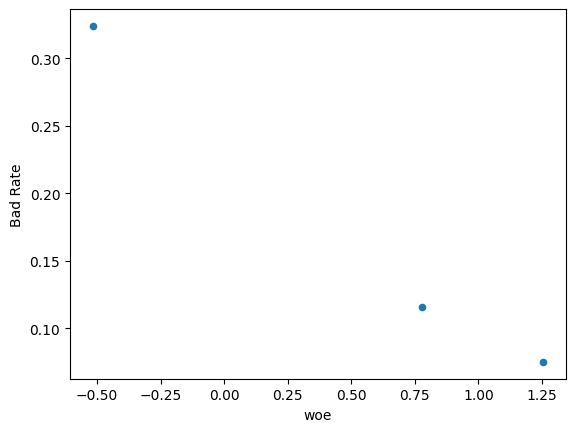

In [318]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [319]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

In [320]:
merged

,person_home_ownership_cat_binned,Bad_Rate,Count,% Population,Value_Range
1,OWN,0.075229,2951,6.557778,RENT
0,MORTGAGE,0.115961,18489,41.086667,OWN
2,RENT,0.324024,23560,52.355556,MORTGAGE


In [321]:
merged_final = merged.merge(iv_df, on = var + '_cat_binned', how = 'left')

In [322]:
merged_final

,person_home_ownership_cat_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,OWN,0.075229,2951,6.557778,RENT,2951,222,2729,0.075229,1.0,0.077971,0.0222,0.055771,1.256250,0.070063,-2.509013
1,MORTGAGE,0.115961,18489,41.086667,OWN,18489,2144,16345,0.115961,2.0,0.467000,0.2144,0.252600,0.778486,0.196646,-2.031249
2,RENT,0.324024,23560,52.355556,MORTGAGE,23560,7634,15926,0.324024,3.0,0.455029,0.7634,-0.308371,-0.517422,0.159558,-0.735341


In [323]:
lstbin

['RENT', 'OWN', 'MORTGAGE']

In [324]:
list(merged_final['Value_Range'])

['RENT', 'OWN', 'MORTGAGE']

In [325]:
dict(zip(merged_final[var + '_cat_binned'],merged_final['woe']))

{'OWN': 1.256250170340691,
 'MORTGAGE': 0.7784858284722503,
 'RENT': -0.5174219289831528}

#previous_loan_defaults_on_file

In [326]:
var = 'previous_loan_defaults_on_file'

In [327]:
data['previous_loan_defaults_on_file'] = data['previous_loan_defaults_on_file'].map({'Yes': 'No', 'No': 'Yes'})


In [328]:
data[var].isna().sum()

np.int64(0)

In [329]:
data[var].value_counts()

,count
previous_loan_defaults_on_file,
No,22858
Yes,22142


In [330]:
data[var].unique()

array(['Yes', 'No'], dtype=object)

## Int Bins

In [331]:
init_lstbin = list(data[var].unique())

In [332]:
init_lstbin

['Yes', 'No']

In [333]:
lstbin = ['Yes', 'No']



In [334]:
len(data)

45000

In [335]:
data[var + '_cat'] = data[var]

In [336]:
merged = CAT_plot_bad_rate_num_updated(data, var + '_cat', lstbin)

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range
0,No,0.00000,22858,50.795556,Yes
1,Yes,0.45163,22142,49.204444,No


,previous_loan_defaults_on_file_cat
count,45000
unique,2
top,No
freq,22858


In [337]:
data[var + '_cat_binned'].nunique()

2

In [338]:
feat_cat_supbins = CategoricalFeature_NoMean_SupplyBins(data, var + '_cat_binned', 'loan_status')

In [339]:
iv = IV_NoMean_SupplyBins()

In [340]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,previous_loan_defaults_on_file_cat_binned,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,No,22858,0,22858,0.00000,1.0,0.653086,0.0,0.653086,inf,inf
1,Yes,22142,10000,12142,0.45163,2.0,0.346914,1.0,-0.653086,-1.058678,0.691407


Information value:  inf


## Modified

In [341]:
data['person_home_ownership_cat'] = data['person_home_ownership_cat'].replace({'OTHER': 'RENT'})

In [342]:
data[var].value_counts()

,count
previous_loan_defaults_on_file,
No,22858
Yes,22142


In [343]:
lstbin = ['Yes', 'No']

In [344]:
dict_var = dict(data[var + '_cat'].value_counts())

In [345]:
lstToGroup = [k for k,v in dict_var.items() if v < 100]

In [346]:
len(data)

45000

In [347]:
for i in lstToGroup:
    lstbin.remove(i)

In [348]:
len(lstbin)

2

In [349]:
lstbin

['Yes', 'No']

In [350]:
data[var + '_cat'].nunique()

2

In [351]:
merged = CAT_plot_bad_rate_num_updated(data, var + '_cat', lstbin)

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range
0,No,0.00000,22858,50.795556,Yes
1,Yes,0.45163,22142,49.204444,No


,previous_loan_defaults_on_file_cat
count,45000
unique,2
top,No
freq,22858


In [352]:
data[var + '_cat_binned'].nunique()

2

In [353]:
feat_cat_supbins = CategoricalFeature_NoMean_SupplyBins(data, var + '_cat_binned', 'loan_status')

In [354]:
iv = IV_NoMean_SupplyBins()

In [355]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,previous_loan_defaults_on_file_cat_binned,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,No,22858,0,22858,0.00000,1.0,0.653086,0.0,0.653086,inf,inf
1,Yes,22142,10000,12142,0.45163,2.0,0.346914,1.0,-0.653086,-1.058678,0.691407


Information value:  inf


### woe_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

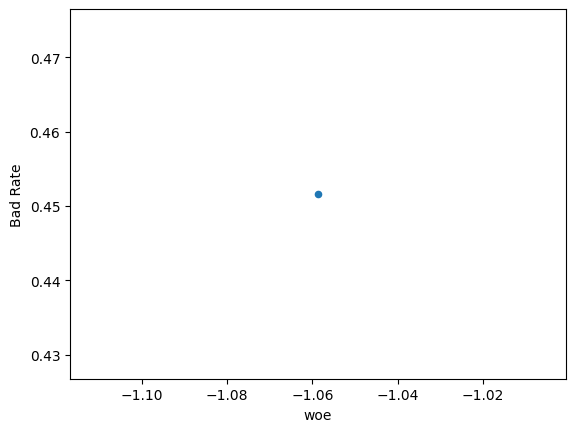

In [356]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [357]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



In [358]:
merged

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range
0,No,0.00000,22858,50.795556,Yes
1,Yes,0.45163,22142,49.204444,No


In [359]:
merged_final = merged.merge(iv_df, on = var + '_cat_binned', how = 'left')

In [360]:
merged_final

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,No,0.00000,22858,50.795556,Yes,22858,0,22858,0.00000,1.0,0.653086,0.0,0.653086,inf,inf,-inf
1,Yes,0.45163,22142,49.204444,No,22142,10000,12142,0.45163,2.0,0.346914,1.0,-0.653086,-1.058678,0.691407,-0.194085


In [361]:
lstbin

['Yes', 'No']

In [362]:
list(merged_final['Value_Range'])

['Yes', 'No']

In [363]:
dict(zip(merged_final[var + '_cat_binned'],merged_final['woe']))

{'No': inf, 'Yes': -1.0586775447811714}

#previous_loan_defaults_on_file

In [364]:
var = 'previous_loan_defaults_on_file'

In [365]:
data['previous_loan_defaults_on_file'] = data['previous_loan_defaults_on_file'].map({'Yes': 'No', 'No': 'Yes'})


In [366]:
data[var].isna().sum()

np.int64(0)

In [367]:
data[var].value_counts()

,count
previous_loan_defaults_on_file,
Yes,22858
No,22142


In [368]:
data[var].unique()

array(['No', 'Yes'], dtype=object)

## Int Bins

In [369]:
init_lstbin = list(data[var].unique())

In [370]:
init_lstbin

['No', 'Yes']

In [371]:
lstbin = ['Yes', 'No']



In [372]:
len(data)

45000

In [373]:
data[var + '_cat'] = data[var]

In [374]:
merged = CAT_plot_bad_rate_num_updated(data, var + '_cat', lstbin)

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range
1,Yes,0.00000,22858,50.795556,Yes
0,No,0.45163,22142,49.204444,No


,previous_loan_defaults_on_file_cat
count,45000
unique,2
top,Yes
freq,22858


In [375]:
data[var + '_cat_binned'].nunique()

2

In [376]:
feat_cat_supbins = CategoricalFeature_NoMean_SupplyBins(data, var + '_cat_binned', 'loan_status')

In [377]:
iv = IV_NoMean_SupplyBins()

In [378]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,previous_loan_defaults_on_file_cat_binned,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,No,22142,10000,12142,0.45163,2.0,0.346914,1.0,-0.653086,-1.058678,0.691407
1,Yes,22858,0,22858,0.00000,1.0,0.653086,0.0,0.653086,inf,inf


Information value:  inf


## Modified

In [379]:
data['person_home_ownership_cat'] = data['person_home_ownership_cat'].replace({'OTHER': 'RENT'})

In [380]:
data[var].value_counts()

,count
previous_loan_defaults_on_file,
Yes,22858
No,22142


In [381]:
lstbin = ['Yes', 'No']

In [382]:
dict_var = dict(data[var + '_cat'].value_counts())

In [383]:
lstToGroup = [k for k,v in dict_var.items() if v < 100]

In [384]:
len(data)

45000

In [385]:
for i in lstToGroup:
    lstbin.remove(i)

In [386]:
len(lstbin)

2

In [387]:
lstbin

['Yes', 'No']

In [388]:
data[var + '_cat'].nunique()

2

In [389]:
merged = CAT_plot_bad_rate_num_updated(data, var + '_cat', lstbin)

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range
1,Yes,0.00000,22858,50.795556,Yes
0,No,0.45163,22142,49.204444,No


,previous_loan_defaults_on_file_cat
count,45000
unique,2
top,Yes
freq,22858


In [390]:
data[var + '_cat_binned'].nunique()

2

In [391]:
feat_cat_supbins = CategoricalFeature_NoMean_SupplyBins(data, var + '_cat_binned', 'loan_status')

In [392]:
iv = IV_NoMean_SupplyBins()

In [393]:
iv_df, iv_value = iv.calculate_iv(feat_cat_supbins, 'loan_status')
display(iv_df)
print('Information value: ', iv_value)

,previous_loan_defaults_on_file_cat_binned,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv
0,No,22142,10000,12142,0.45163,2.0,0.346914,1.0,-0.653086,-1.058678,0.691407
1,Yes,22858,0,22858,0.00000,1.0,0.653086,0.0,0.653086,inf,inf


Information value:  inf


### woe_mapping

<Axes: xlabel='woe', ylabel='Bad Rate'>

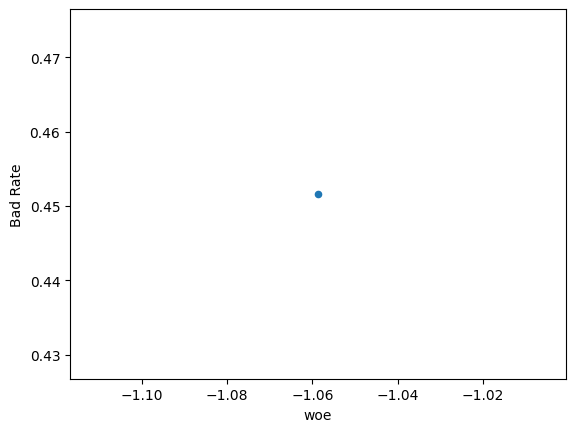

In [394]:
iv_df.plot(x = 'woe', y = 'Bad Rate', kind = 'scatter')

In [395]:
iv_df['log_odds'] = np.log(iv_df['Bad Rate']/(1-iv_df['Bad Rate']))

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



In [396]:
merged

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range
1,Yes,0.00000,22858,50.795556,Yes
0,No,0.45163,22142,49.204444,No


In [397]:
merged_final = merged.merge(iv_df, on = var + '_cat_binned', how = 'left')

In [398]:
merged_final

,previous_loan_defaults_on_file_cat_binned,Bad_Rate,Count,% Population,Value_Range,count,bad,good,Bad Rate,rank,perc_good,perc_bad,perc_diff,woe,iv,log_odds
0,Yes,0.00000,22858,50.795556,Yes,22858,0,22858,0.00000,1.0,0.653086,0.0,0.653086,inf,inf,-inf
1,No,0.45163,22142,49.204444,No,22142,10000,12142,0.45163,2.0,0.346914,1.0,-0.653086,-1.058678,0.691407,-0.194085


In [399]:
lstbin

['Yes', 'No']

In [400]:
list(merged_final['Value_Range'])

['Yes', 'No']

In [401]:
dict(zip(merged_final[var + '_cat_binned'],merged_final['woe']))

{'Yes': inf, 'No': -1.0586775447811714}